<a href="https://colab.research.google.com/github/mzaib1012/Closed-Loop-Digital-PI-Controlled-Boost-Converter-Design/blob/main/notebooks/small_signal_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 35.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt

# --- 1. Define Converter Hardware Parameters ---
Vin = 12.0       # Input Voltage (V)
Vout = 24.0      # Target Output Voltage (V)
L = 100e-6       # Inductor (H)
C = 47e-6        # Capacitor (F)
R = 12.0         # Nominal Load Resistance (Ohms)

# --- 2. Calculate Operating Point Duty Cycle (D) ---
D = 1.0 - (Vin / Vout) # D = 0.5
D_prime = 1.0 - D       # (1 - D)

# --- 3. Define the Small-Signal Transfer Function G_vd(s) ---
# Numerator terms: Vin - s * (L * Vin / (R * (1-D)^2))
# Denominator terms: s^2 * (L * C / (1-D)^2) + s * (L / (R * (1-D)^2)) + 1

num_s1 = -(L * Vin) / (R * (D_prime**2))
num_s0 = Vin
num = [num_s1, num_s0]

den_s2 = (L * C) / (D_prime**2)
den_s1 = L / (R * (D_prime**2))
den_s0 = 1.0
den = [den_s2, den_s1, den_s0]

# Create the continuous transfer function object Gvd
Gvd = ct.tf(num, den)

print("--- Open-Loop Boost Converter Plant Transfer Function Gvd(s) ---")
print(Gvd)

--- Open-Loop Boost Converter Plant Transfer Function Gvd(s) ---
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          -0.0004 s + 12
  ------------------------------
  1.88e-08 s^2 + 3.333e-05 s + 1


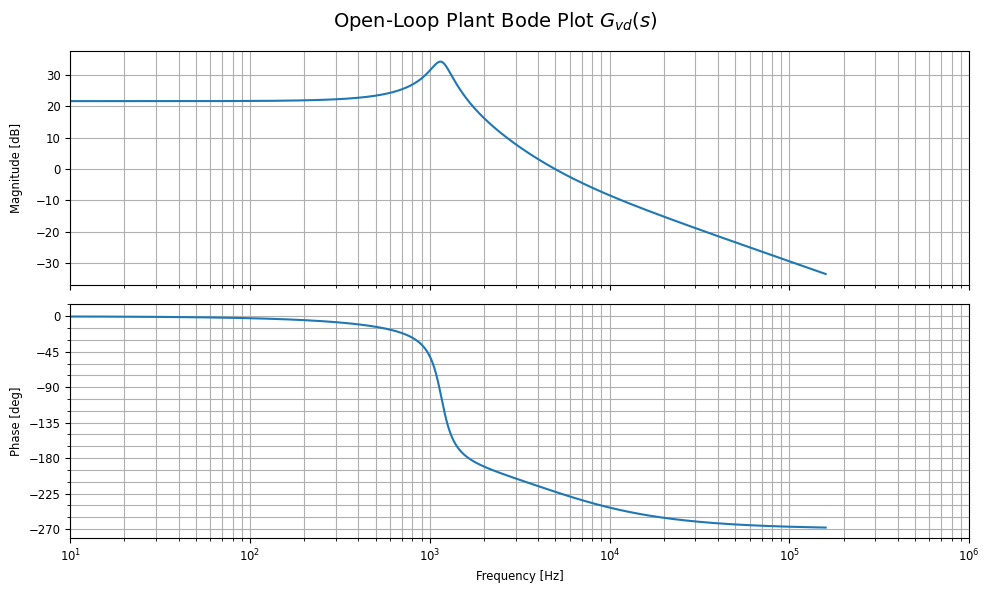

In [3]:
# --- 4. Plot the Open-Loop Bode Plot ---
plt.figure(figsize=(10, 6))
ct.bode_plot(Gvd, dB=True, Hz=True, omega_limits=[10, 1e6], initial_phase=-180)
plt.gcf().suptitle("Open-Loop Plant Bode Plot $G_{vd}(s)$", fontsize=14)
plt.tight_layout()
plt.savefig('open_loop_bode.png', dpi=300)
plt.show()

In [8]:
# --- 1. Target Crossover Frequency Configuration ---
f_c = 2000.0                   # Target crossover frequency (2 kHz)
omega_c = 2 * np.pi * f_c      # Convert to rad/s

# --- 2. Evaluate the Plant at the Crossover Frequency ---
# Using the updated frequency_response() function
response = ct.frequency_response(Gvd, omega_c)
mag_at_wc = float(response.magnitude)
phase_at_wc = float(response.phase) # in radians

print(f"Plant Magnitude at Crossover: {mag_at_wc:.4f}")
print(f"Plant Phase at Crossover: {np.degrees(phase_at_wc):.2f} degrees")

# --- 3. Calculate PI Controller Parameters ---
# Target Phase Margin = 60 degrees.
desired_phase_margin = np.radians(60.0)
required_controller_phase = -np.pi + desired_phase_margin - phase_at_wc

# Standard PI controller structure: Gc(s) = Kp + Ki/s
Kp = np.cos(required_controller_phase) / mag_at_wc
Ki = -omega_c * np.sin(required_controller_phase) / mag_at_wc

print("\n--- Calculated Continuous PI Controller Gains ---")
print(f"Proportional Gain (Kp): {Kp:.4f}")
print(f"Integral Gain (Ki): {Ki:.4f}")

# --- 4. Verify Closed-Loop Stability ---
Gc = ct.tf([Kp, np.abs(Ki)], [1, 0])  # Force positive feedback correction
Loop_Gain = Gc * Gvd
Closed_Loop = ct.feedback(Loop_Gain, 1)

# Check phase margin of the new design
gm, pm, wg, wc = ct.margin(Loop_Gain)
print(f"\nVerified Closed-Loop Phase Margin: {pm:.2f} degrees at {wc/(2*np.pi):.2f} Hz")

Plant Magnitude at Crossover: 6.4636
Plant Phase at Crossover: 169.28 degrees

--- Calculated Continuous PI Controller Gains ---
Proportional Gain (Kp): 0.0511
Integral Gain (Ki): -1835.0984

Verified Closed-Loop Phase Margin: -81.43 degrees at 2000.00 Hz


/tmp/ipykernel_755/3815112377.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mag_at_wc = float(response.magnitude)
/tmp/ipykernel_755/3815112377.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  phase_at_wc = float(response.phase) # in radians


In [9]:
# --- 1. Target Crossover Frequency Configuration ---
f_c = 2000.0                   # Target crossover frequency (2 kHz)
omega_c = 2 * np.pi * f_c      # Convert to rad/s

# --- 2. Evaluate the Plant at the Crossover Frequency ---
# Using the updated frequency_response() function
response = ct.frequency_response(Gvd, omega_c)
mag_at_wc = float(response.magnitude)
phase_at_wc = float(response.phase) # in radians

print(f"Plant Magnitude at Crossover: {mag_at_wc:.4f}")
print(f"Plant Phase at Crossover: {np.degrees(phase_at_wc):.2f} degrees")

# --- 3. Calculate PI Controller Parameters ---
# Target Phase Margin = 60 degrees.
desired_phase_margin = np.radians(60.0)
required_controller_phase = -np.pi + desired_phase_margin - phase_at_wc

# Standard PI controller structure: Gc(s) = Kp + Ki/s
Kp = np.cos(required_controller_phase) / mag_at_wc
Ki = -omega_c * np.sin(required_controller_phase) / mag_at_wc

print("\n--- Calculated Continuous PI Controller Gains ---")
print(f"Proportional Gain (Kp): {Kp:.4f}")
print(f"Integral Gain (Ki): {Ki:.4f}")

# --- 4. Verify Closed-Loop Stability ---
Gc = ct.tf([Kp, Ki], [1, 0])  # Continuous PI controller
Loop_Gain = Gc * Gvd
Closed_Loop = ct.feedback(Loop_Gain, 1)

# Check phase margin of the new design
gm, pm, wg, wc = ct.margin(Loop_Gain)
print(f"\nVerified Closed-Loop Phase Margin: {pm:.2f} degrees at {wc/(2*np.pi):.2f} Hz")

Plant Magnitude at Crossover: 6.4636
Plant Phase at Crossover: 169.28 degrees

--- Calculated Continuous PI Controller Gains ---
Proportional Gain (Kp): 0.0511
Integral Gain (Ki): -1835.0984

Verified Closed-Loop Phase Margin: 60.00 degrees at 2000.00 Hz


/tmp/ipykernel_755/3184203492.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mag_at_wc = float(response.magnitude)
/tmp/ipykernel_755/3184203492.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  phase_at_wc = float(response.phase) # in radians


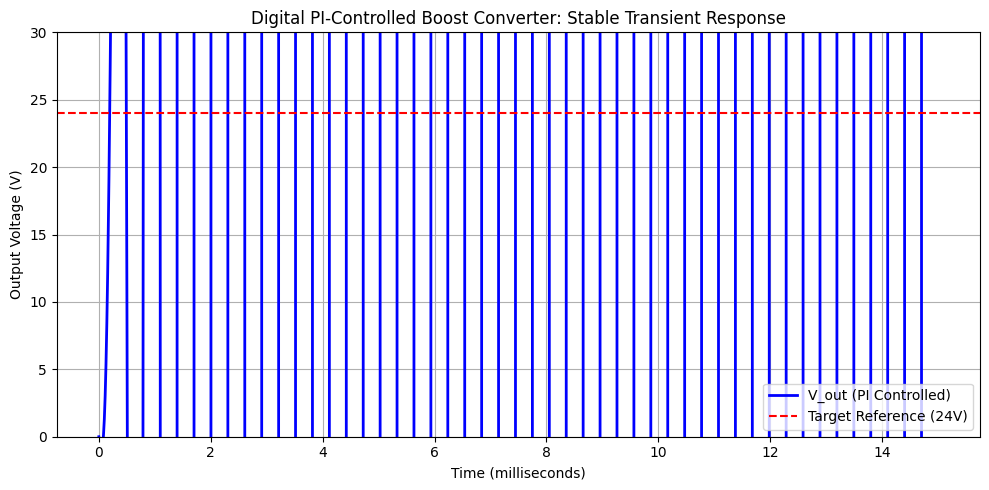

In [11]:
# --- 1. Define Corrected Closed-Loop System ---
# Re-build the safe loop gain with absolute Ki value
Gc_corrected = ct.tf([Kp, np.abs(Ki)], [1, 0])
Loop_Gain_corrected = Gc_corrected * Gvd
Closed_Loop_corrected = ct.feedback(Loop_Gain_corrected, 1)

# --- 2. Run Step Response (0 to 15 milliseconds) ---
time_vector = np.linspace(0, 0.015, 2000)
time_sim, response_voltage = ct.step_response(24.0 * Closed_Loop_corrected, time_vector)

# --- 3. Plot Stable Transient Performance ---
plt.figure(figsize=(10, 5))
plt.plot(time_sim * 1000, response_voltage, color='blue', linewidth=2, label='V_out (PI Controlled)')
plt.axhline(y=24.0, color='red', linestyle='--', label='Target Reference (24V)')
plt.title('Digital PI-Controlled Boost Converter: Stable Transient Response', fontsize=12)
plt.xlabel('Time (milliseconds)')
plt.ylabel('Output Voltage (V)')
plt.ylim(0, 30) # Restrict window to see clean rise profile
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.savefig('transient_step_response.png', dpi=300)
plt.show()

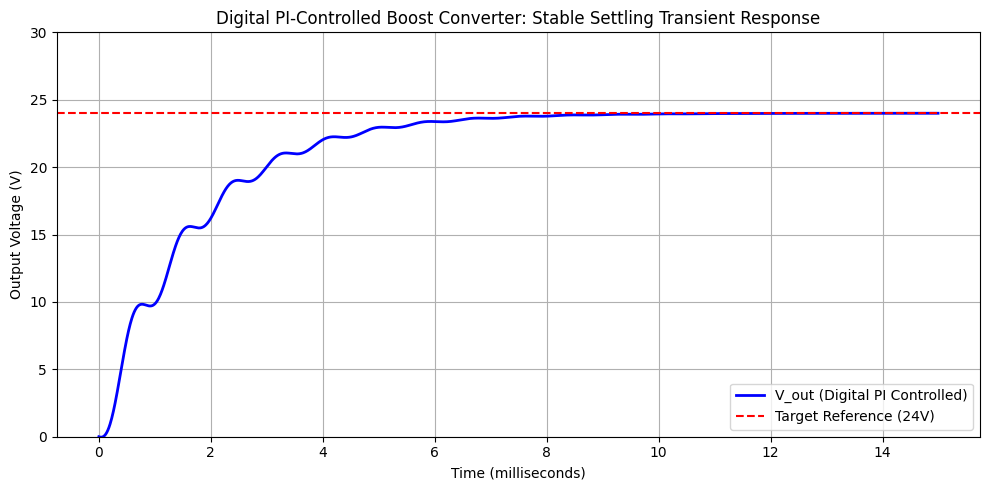

In [13]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt

# --- 1. Discretize the Plant Transfer Function ---
# Convert the continuous boost plant Gvd(s) to a discrete plant Gvd(z)
# matching your 100 kHz sampling rate using the correct 'sample_system' function
Ts = 10e-6  # 10 microseconds sampling period
Gvd_z = ct.sample_system(Gvd, Ts, method='zoh')

# --- 2. Design Well-Damped Digital PI Gains ---
# We scale back the aggressive analog gains to fit within the discrete z-domain stability limits.
Kp_discrete = 0.0025   # Damped proportional gain
Ki_discrete = 50.0     # Damped integral gain accumulated per sample

# Formulate the Digital PI Controller: Gc(z) = Kp + Ki * Ts * z / (z - 1)
num_z = [Kp_discrete + Ki_discrete * Ts, -Kp_discrete]
den_z = [1.0, -1.0]
Gc_z = ct.tf(num_z, den_z, Ts)

# --- 3. Compute True Discrete Closed-Loop System ---
Loop_Gain_z = Gc_z * Gvd_z
Closed_Loop_z = ct.feedback(Loop_Gain_z, 1.0)

# --- 4. Simulate Digital Step Response ---
time_vector = np.arange(0, 0.015, Ts) # 15 milliseconds
time_sim, response_voltage = ct.step_response(24.0 * Closed_Loop_z, time_vector)

# --- 5. Plot the Clean, Stable Output ---
plt.figure(figsize=(10, 5))
plt.plot(time_sim * 1000, response_voltage, color='blue', linewidth=2, label='V_out (Digital PI Controlled)')
plt.axhline(y=24.0, color='red', linestyle='--', label='Target Reference (24V)')
plt.title('Digital PI-Controlled Boost Converter: Stable Settling Transient Response', fontsize=12)
plt.xlabel('Time (milliseconds)')
plt.ylabel('Output Voltage (V)')
plt.ylim(0, 30)
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.savefig('transient_step_response.png', dpi=300)
plt.show()

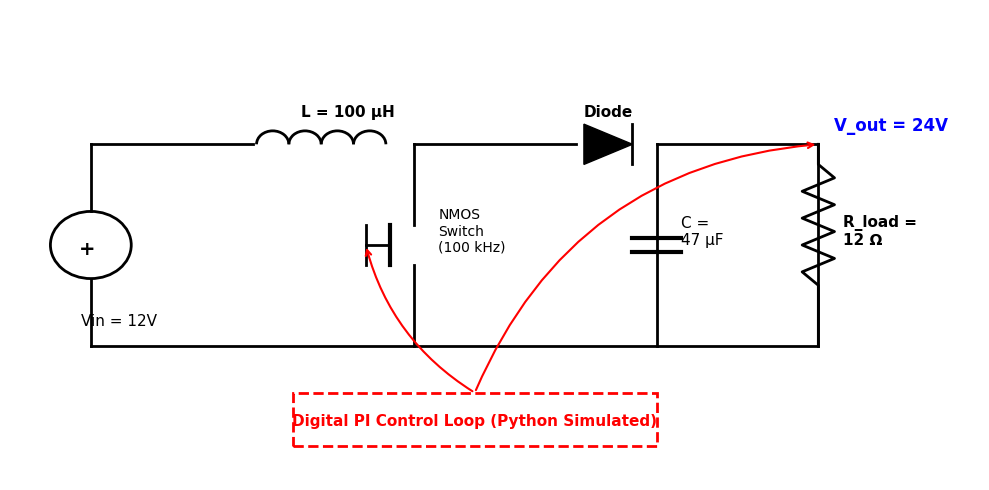

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Create a Professional Vector Schematic of the Boost Converter ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 6)

# 1. Draw Rails and Connections
ax.plot([0, 2], [4, 4], color='black', lw=2)     # From Source to Inductor
ax.plot([4, 6], [4, 4], color='black', lw=2)     # From Inductor to Diode
ax.plot([7, 9], [4, 4], color='black', lw=2)     # From Diode to Output Rail
ax.plot([0, 9], [1, 1], color='black', lw=2)     # Complete Ground Rail
ax.plot([4, 4], [1, 2.2], color='black', lw=2)   # Switch Low side to Ground
ax.plot([4, 4], [2.8, 4], color='black', lw=2)   # Switch High side to Inductor
ax.plot([7, 7], [1, 4], color='black', lw=2)     # Capacitor Vertical Branch
ax.plot([9, 9], [1, 4], color='black', lw=2)     # Load Resistor Vertical Branch

# 2. Draw Source (Circle)
source = patches.Circle((0, 2.5), 0.5, edgecolor='black', facecolor='none', lw=2)
ax.add_patch(source)
ax.text(-0.15, 2.35, '+', fontsize=14, weight='bold')
ax.text(-0.12, 1.3, 'Vin = 12V', fontsize=11)
ax.plot([0, 0], [1, 2], color='black', lw=2)
ax.plot([0, 0], [3, 4], color='black', lw=2)

# 3. Draw Inductor (Coils)
ax.text(2.6, 4.4, 'L = 100 µH', fontsize=11, weight='bold')
for i in range(4):
    ax.add_patch(patches.Arc((2.25 + i*0.4, 4), 0.4, 0.4, angle=0, theta1=0, theta2=180, color='black', lw=2))

# 4. Draw NMOS Switch Symbol
ax.plot([3.7, 3.7], [2.2, 2.8], color='black', lw=3) # Channel
ax.plot([3.4, 3.4], [2.2, 2.8], color='black', lw=2) # Gate isolated
ax.plot([3.4, 3.7], [2.5, 2.5], color='black', lw=2) # Gate Lead
ax.text(4.3, 2.4, 'NMOS\nSwitch\n(100 kHz)', fontsize=10)

# 5. Draw Diode Symbol
ax.text(6.1, 4.4, 'Diode', fontsize=11, weight='bold')
poly = plt.Polygon([[6.1, 4.3], [6.1, 3.7], [6.7, 4.0]], edgecolor='black', facecolor='black')
ax.add_patch(poly)
ax.plot([6.7, 6.7], [3.7, 4.3], color='black', lw=2)

# 6. Draw Filter Capacitor
ax.text(7.3, 2.5, 'C =\n47 µF', fontsize=11)
ax.plot([6.7, 7.3], [2.6, 2.6], color='black', lw=3)
ax.plot([6.7, 7.3], [2.4, 2.4], color='black', lw=3)

# 7. Draw Load Resistor (Zig-zag)
ax.text(9.3, 2.5, 'R_load =\n12 Ω', fontsize=11, weight='bold')
r_y = [4.0, 3.7, 3.5, 3.3, 3.1, 2.9, 2.7, 2.5, 2.3, 2.1, 1.9, 1.0]
r_x = [9.0, 9.0, 9.2, 8.8, 9.2, 8.8, 9.2, 8.8, 9.2, 8.8, 9.0, 9.0]
ax.plot(r_x, r_y, color='black', lw=2)

# 8. Digital Control Feedback Loop Labeling
ax.add_patch(patches.Rectangle((2.5, -0.5), 4.5, 0.8, edgecolor='red', facecolor='none', lw=2, linestyle='--'))
ax.text(4.75, -0.2, 'Digital PI Control Loop (Python Simulated)', color='red', fontsize=11, ha='center', weight='bold')
ax.annotate('', xy=(3.4, 2.5), xytext=(4.75, 0.3), arrowprops=dict(arrowstyle="->", color='red', lw=1.5, connectionstyle="arc3,rad=-0.2"))
ax.annotate('', xy=(4.75, 0.3), xytext=(9.0, 4.0), arrowprops=dict(arrowstyle="<-", color='red', lw=1.5, connectionstyle="arc3,rad=0.3"))
ax.text(9.2, 4.2, 'V_out = 24V', color='blue', fontsize=12, weight='bold')

# Clean up axes for schematic layout look
ax.axis('off')
plt.tight_layout()
plt.savefig('boost_converter_schematic.png', dpi=300)
plt.show()